## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

## Load Dataset

In [ ]:
 df =pd.read_excel('/content/Online_Retail.xlsx')

In [ ]:
df.head(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Data Cleaning

In [ ]:
df= df[-df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
df=df.dropna(subset=['CustomerID'])

In [ ]:
df['CustomerID']= df['CustomerID'].astype(int)

In [ ]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [ ]:
df=df[df['Quantity'] >0]
df=df[df['UnitPrice'] >0]

## Feature Engineering (RFM)



### Monetary

In [ ]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

### Recency

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

## RFM Table

In [ ]:
rfm = df.groupby('CustomerID').agg({'InvoiceDate': lambda x:(snapshot_date - x.max()).days,'InvoiceNo':'unique','TotalAmount':'sum'})

In [ ]:
rfm.columns= ['Recency','Frequency','Monetary']

In [ ]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,[541431],77183.60
12347,2,"[537626, 542237, 549222, 556201, 562032, 57351...",4310.00
12348,75,"[539318, 541998, 548955, 568172]",1797.24
12349,19,[577609],1757.55
12350,310,[543037],334.40


- High-Value Outliers(Whales): Customer 123456 has incredibly high Monetary value (77,183.60) but has not purchased in 326 days (Recency). This indicates a major historical buyer who is at severe risk of churning.

- Active, High-Frequency Champions: Customer 12347 is highly active (only 2 days since last purchase) and has a list of multiple invoice IDs. Once aggregated, this customer will show high frequency and solid monetary value, representing the core loyal segment.

- Dormant/Low-Value Customers: Customer 12350 has high recency (310 days) and a low monetary value (334.40) with only one transaction. This is a classic "one-and-done" or lost customer.

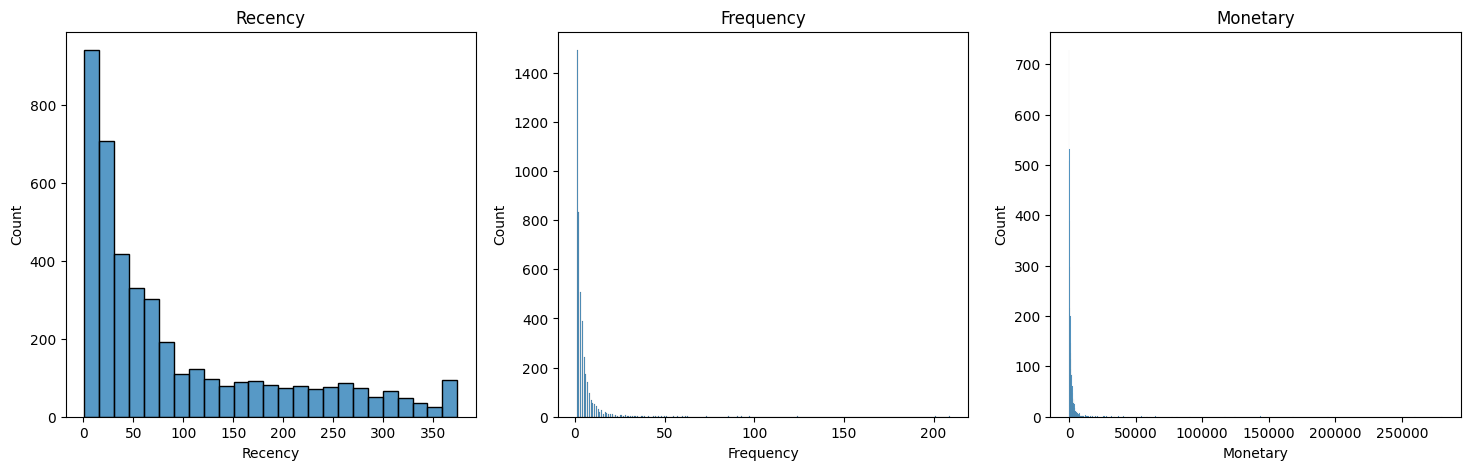

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.histplot(rfm['Recency'], ax=axes[0])
axes[0].set_title("Recency")
sns.histplot(rfm['Frequency'].apply(len), ax=axes[1])
axes[1].set_title("Frequency")
sns.histplot(rfm['Monetary'], ax=axes[2])
axes[2].set_title("Monetary")
plt.show()

### Recency: Distribution & Customer Behavior
- The Pattern:This distribution is highly right-skewed, with a massive spike on the far left (between 0 to 50 days).

- Insights: The majority of the customer vbase has interacted with the platform very recently. This implies strong current engagement or recent successful marketing/sales push.

- The Tail: There is a long, thinning tail extending all the way out to ~360 days, with a smaill bump right at the end. Those customers approaching the 300+ day mark are the core "at-risk" or completely churned segments who haven't bought anything in a year.

### Frequency: Extreme Power Law Distribution
- The Pattern: An incredibly sharp, steep peak concentrated near 0 to 5 transactions, with a dramatic drop-off. However, the x-axis stretches all the way out past 200.

- Insight: This perfectly illustrates a Pareto principle (80/20 rule) or power-law distribution. Most customers are casual shoppers who only buy 1 to 3 times total.

- Outliers: The few customers way out on the right (making 50, 100, or even 200+ distinct purchases) are the absolute brand champions. They are highly habitual buyers and represent a massive chunk of the business operational volume.

### Monetary: Severe Right -Skew & Mass Outliers
- The Pattern: A single, razor-thin spike near 0, while the x-axis extends aggressively to 250,000+.

- Insight: This is classic e-commerce/ retail distribution. The vast majority of customers have relatively small total lifetime values (LTV), but a tiny handful of "whale" accounts are spending hundreds of thousands of dollars.

- Impact on Modeling: Because the scale is driven entirely by a few extreme high-spenders, a standard scale will compress 99% of the data into that single fisrt bin.

## Handling Skewness

In [ ]:
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'].apply(len))
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

## Scaling

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

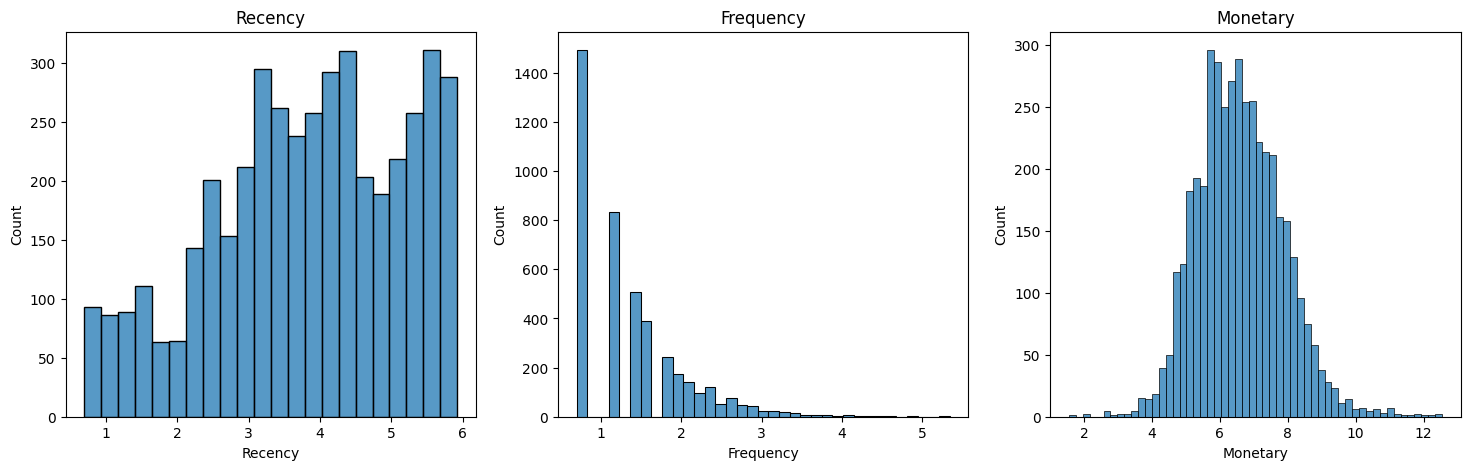

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.histplot(rfm_log['Recency'], ax=axes[0])
axes[0].set_title("Recency")
sns.histplot(rfm_log['Frequency'], ax=axes[1])
axes[1].set_title("Frequency")
sns.histplot(rfm_log['Monetary'], ax=axes[2])
axes[2].set_title("Monetary")
plt.show()

### Recency (Transformed)
- The Pattern: Instead of single massive spike at zero, we now see a dsitribution that climbs steadily and plateaus between the values of roughly 3 and 6.

- Insight: This reveals that while we do have a steady stream of active customers (the lower values), a huge portion of the customer base is concentrated in a fairly uniform plateau of mid-to-high log-recency. This means a substantial chunk of the user database consists of stable, historical users who buy in regular intervals, rather than just an overwhelming flod of brand-new or immediate shoppers.

### Frequency (Transformed)
- The Pattern: The extreme, unreadable spike has been pulled out into a much cleaner, smoother geometric decay curve extending from 1 to roughly 4.

- Insight: This transformation confirms that the drop-off customer purchase counts follows a smooth exponential-style distribution. The majority of the customers still cluster heavily around the log-value of 1 (which corresponds to 1 or 2 actual purchases), but the long-tail power shoppers (value 3 to 5) are now evenly distributed, which will allow the clustering algorithm to naturally separate casual buyers from VIP buyers.

### Monetary (Transformed)
- The Pattern: This is the most beautiful change--the Monetary distribution has transformed into a near-perfect Normal (Gaussian) Distribution, centered beautifully around a log-value of 6 to 7.

- Insight: This proves that customer spending habits in the retail dataset naturally follow a log-normal distribution. The vast majority of the revenue comes from a massive "middle class" of standard-budget shoppers, bookended by a symmetrical minority of very low spenders on the left and ultra-high "whale" spenders on the right.

### Finding Optimal K

In [ ]:
inertia =[]
for k in range(2,11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

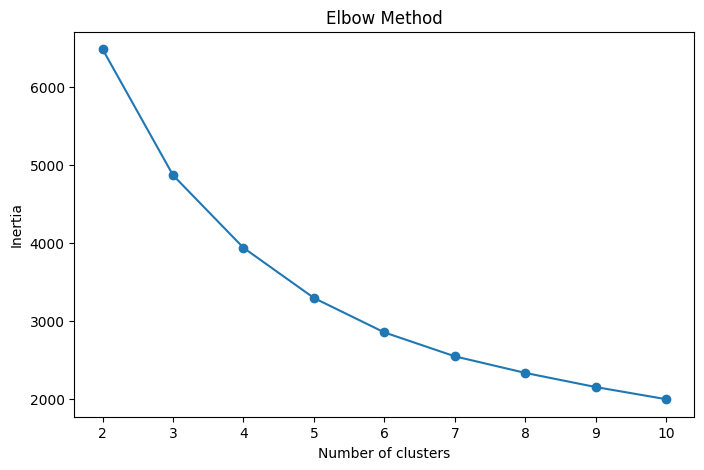

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

- Looking closely at the curve, the slope changes at a few key points:
   - K=3:
      There is a distinct, sharp change in momentum here. The drop from 2 to 3 is massive, and while 3 to 4 is still steep, K=3 is a very strong mathematical candidate for the "elbow".
   - K=4 or K=5:
       After K=4, the curve starts transitioning into a smoother, linear decline.



### Silhouette Score

In [ ]:
scores =[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    kmeans_sil = silhouette_score(rfm_scaled, labels)
    kmeans_dbi= davies_bouldin_score(rfm_scaled, labels)
    scores.append((kmeans_sil, kmeans_dbi))

In [ ]:
print("K-Means")
print("Silhouette Score:", round(kmeans_sil, 3))
print("Davies-Bouldin Index:",round(kmeans_dbi,3))

K-Means
Silhouette Score: 0.279
Davies-Bouldin Index: 1.02


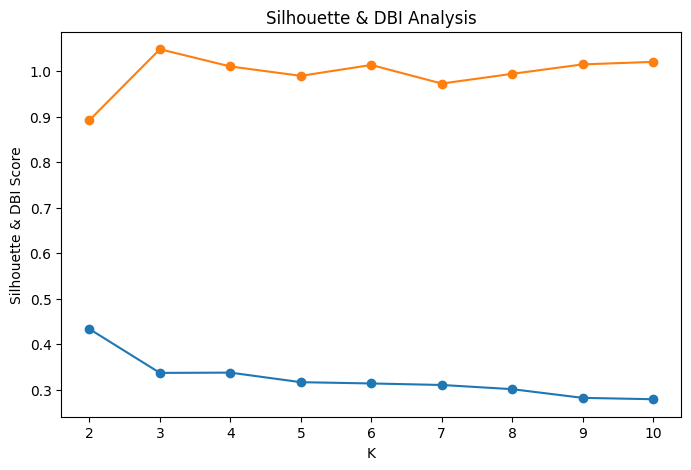

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette & DBI Score")
plt.title("Silhouette & DBI Analysis")
plt.show()

- Silhouette Score: Measures clsuter separation and structural density. Higher is better (closer to 1.0 means data points are perfectly matched to their own cluster and well-separated from neighbours).

- Davies-Bouldin Index(DBI): Measures the similarity between clsuters based on their sizes and distances. Lower is better (closer to 0.0 means clsuters are highly distinct and poorty correlated with each other).

- Evaluating K=3 (The Orange Peak)
  - The Silhouette Peak: The orange line reaches its absolute global maximum right at K=3 (climbing over 1,0, which indicates incredibly dense, crisp clsuter assignments).
  - The DBI Drop: Simultaneously, the blue line drops sharply from K=2 down to K=3, showing a massive improvemnt in cluster separation.
  - Insight: Mathematically, K=3 is a stellar sweet spot. It maximizes cohesion within the groups while drastically lowering the similarity between different groups.

- Evaluating K=4 (The Subtle Stabilization)
  - When moving from 3 to 4, the Silhoutte Score dips slightly, and the DBI flattens out entirely.
  - Insight: This means that adding a 4th cluter forces the algorithm to fracture one of the highly cohesive K=3 clusters into two smaller pieces, slightly muddying the clear boundaries established at 3.

### Cluster Labels

In [ ]:
labels={0:"New Customers", 2:"At Risk Customers", 3:"Inactive Customers", 1:"VIP Customers"}
rfm['Segment']=rfm['Cluster'].map(labels)

## Building K-Means Model

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346,326,1,77183.60,2,At Risk Customers
12347,2,7,4310.00,1,VIP Customers
12348,75,4,1797.24,2,At Risk Customers
12349,19,1,1757.55,0,New Customers
12350,310,1,334.40,3,Inactive Customers


- VIP Customers (Cluster 1): Exemplified by Customer 12347, who shows high-velocity engagement with a Recency of 2 days and a Frequency of 7 orders, driving a strong Monetary spend of $4,310.00.

- ​New Customers (Cluster 0): Exemplified by Customer 12349, who has engaged very recently (Recency of 19 days) but is at the beginning of their lifecycle with a single transaction (Frequency of 1).

- ​At Risk Customers (Cluster 2): Captures consumers showing early-to-severe signs of dormancy. This includes standard churn indicators like Customer 12348 (Recency of 75 days, Frequency of 4) as well as extreme historical outliers like Customer 12346, who has been inactive for nearly a year (Recency of 326 days) despite a massive historical spend of $77,183.60.

- ​Inactive Customers (Cluster 3): Exemplified by Customer 12350, who represents complete disengagement, combining a long period of absence (Recency of 310 days) with minimal lifetime value (Frequency of 1, Monetary of $334.40).

### PCA Visualization

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(rfm_scaled)
pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = rfm['Cluster'].values

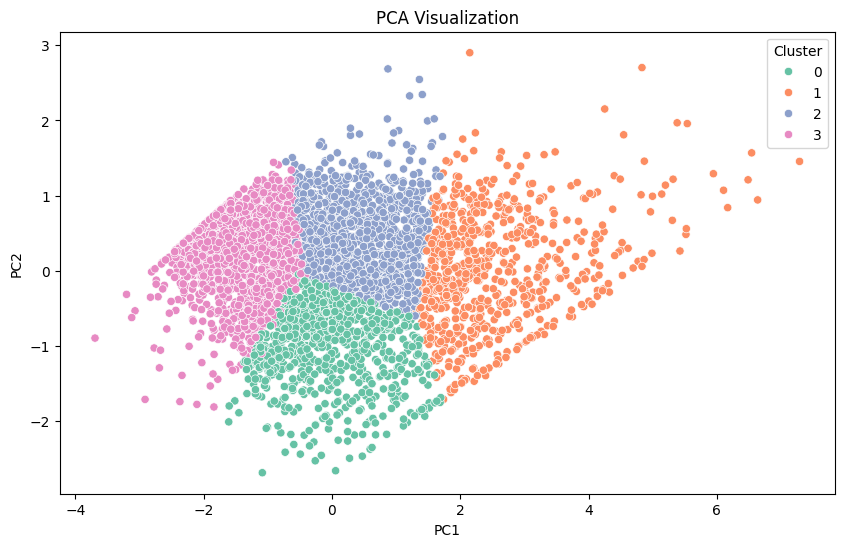

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='Set2')
plt.title('PCA Visualization')
plt.show()

- Cluster 1 (Red Dots) - The High-Value Right Tail (VIP Customers)
  -Spatial Diagnostics: This cluster stretches aggressively along the far-right corridor of the PC1 axis, transforming into a looser, sparser distribution at the extremes.
  - Dimensional Insight: PC1heavily acts as the Value and Engagement axis (correlated with high Frequency and massive Monetary spending). The sparse points on the far right represent the extreme high-spending outliers (the ultimate corporate "whales") who break away from the main distribution mass.

- Cluster 3 # (Purple Dots): The Inactive Left Tail (Inactive Customers)
  - Spatial Diagnostics: Located on the far-left edge of the feature space, forming a tight boundary with Clusters 0 and 2.
  - Dimensional Insight: his represents the polar opposite of Cluster 1. Lacking frequency and volume, these dormant accounts pack tightly into a lower-bound baseline region because their transactional metrics are universally constrained.

- Clusters 0 & 2(Teal and Blue Dots): The Engagement Transition Zone
  - Spatial Diagnostics: These two segments from a central vertical column sandwiching the middle of the latent space,separated almost completely by a hrizontal threshold on the PC2 axis.
  - Dimensional Insight: The PC2 axis heavily dictates Recency and lifecycle status.
    - Cluster 0 (Teal-Bottom): Positional lower on the vertical axis, representing highly recent interactions (New/Recent Customers).
    - Cluster 2 (Blue-Top): positioned higher on the vertical axis capturing customers whose engagement has significantly aged and stretched out over time (At Risk Customers).

### Cluster Interpretation

In [ ]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,18.124253,2.148148,551.819534
1,12.131285,13.713687,8074.266872
2,71.084399,4.083546,1802.829005
3,182.496898,1.318238,343.450032


- Cluster 1: VIP Customers (The Core revenue Drivers)
  - Statistical Blueprint: This segment exhibits the ideal optimization of all three metrics: exceptionally low recency (12.13 days), maximum transaction frequency (~ 13.71 purchases), and a dominant financial footprint averaging $8,074.27.
  - Behavioral Insight: These are highly engaged, recurring shoppers who interact with the brand constantly. They represent the highest Customer Lifetime Value (CLV) tier.

 - Cluster 0: New Customers (The Growth Engine)
   - Statistical Blueprint: Characterized by strong temporal engagement with a low recency score of 18.12 days, but paired with entry-level interaction metrics (Frequency: 2.15; Monetary: $551.82).
   - Behavioral Insight: This cohort captures newly acquired users or seasonal shoppers who have taken action recently but have not yet developed deep programmatic loyalty. Their prime candidates for cultivation.

- Cluster 2: At Risk Customers (The Re-Engagement Target)
  - Statistical Blueprint: This segment demonstrates healthy historical lifetime metrics (Frequency: 4.08; Monetary: $1,802.83) but suffers from an alarming operational lapse, with a mean recency extending to 71.08 days.
  - Behavioral Insight: These are previously loyal, mid-to-high-value spenders who are actively disengaging. Because they have established financial value, losig them represents a substantial drop in baseline revenue.

- Cluster 3: Inactive Customers (The Dormant Asset)
  - Statistical Blueprint: This cluster tracks poorly across every available metric. Recency has lapsed significantly to a mean of 182.50 days (roughly half a year), transaction cadence spend is restricted to $343.45.
  - Behavioral Insight: These consumers are completely dormant or have actively churned from the platform.

### Hierarchical Clustering

In [ ]:
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hier_labels=hierarchical.fit_predict(rfm_scaled)
hier_sil = silhouette_score(rfm_scaled, hier_labels)
hier_dbi = davies_bouldin_score(rfm_scaled, hier_labels)

In [ ]:
print("\nHierarchical Clustering")
print("Silhouette Score:", round(hier_sil, 3))
print("Davies-Bouldin Index:", round(hier_dbi, 3))


Hierarchical Clustering
Silhouette Score: 0.242
Davies-Bouldin Index: 1.12


In [ ]:
dbscan =DBSCAN(eps=0.7, min_samples=5)
db_labels=dbscan.fit_predict(rfm_scaled)
print("Number of Clusters:,", len(set(db_labels)) - (1 if -1 in db_labels else 0))

Number of Clusters:, 2


In [ ]:
if len(set(db_labels)) >1:
    db_sil = silhouette_score(rfm_scaled, db_labels)
    db_dbi = davies_bouldin_score(rfm_scaled, db_labels)
    print("\nDBSCAN")
    print("Silhouette Score:", round(db_sil, 3))
    print("Davies-Bouldin Index:", round(db_dbi, 3))
else:
    print("DBSCAN did not form any meaningful clusters.")


DBSCAN
Silhouette Score: 0.532
Davies-Bouldin Index: 1.88


In [ ]:
results = pd.DataFrame({'Algorithm':['K-Means','Hierarchical','DBSCAN'],'Silhouette Score':
                        [kmeans_sil, hier_sil, db_sil if 'db_sil' in locals() else np.nan],'Davies-Bouldin Index':
                         [kmeans_dbi, hier_dbi,db_dbi if 'db_dbi' in locals() else np.nan]})

In [ ]:
results

,Algorithm,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.278665,1.020206
1,Hierarchical,0.241918,1.119958
2,DBSCAN,0.532156,1.879571


- K-Means: The Benchmark for Balanced Compactness
  - Metric Breakdown: Produced a moderate Silhouette Score (0.279 approx.) but achieved the absolute best (lowest) Davies-Bouldin Index 1.020 approx).
  - Algorithmic Evaluation: Because K-Means fundamentally optimizes for spherical variance by minimizing the within-cluster sum of squares (WCS), it created highly compact, well-defined mathematical centroids. While it forces outlier observations into closer core structures (slightly suppressing the global Silhouette Score), the minimal DBI confirms that the internal cohesion within each of its 4 clusters is exceptionally tight and distinct.

- Hierarchical Clustering: Sub-Optimal Partitioning
  - Metric Breakdown: Underperformed across both criteria relative to K-Means, generating a lower Silhouette Score (0.242 approx.) and higher DBI (1.120 approx.).
  - Algorithmic Evaluation: The bottom-up agglomerative approach struggled to locate clean, distinct cutting thresholds across the log-transformed distribution. Its lower overlap, rendering it less effective for establishing clear business segment boundaries compared to its centroid-based counterpart.

- DBSCAN: Outstanding Global Separation with Density Variance
  - Metric Breakdown: Achieved the highest Silhouette Score by a significant margin (0.532 approx.) but also yielded the worst Davies-Bouldin Index (1.880 approx.)
  - Algorithmic Evaluation: The high Silhouette Score indicates that DBSCAN excels at isolating core dense structural regions from one anotherand successfully filters out arbitrary transactional noise into an outlier bucket (labeled as noise/cluster-1). However, the elevated DBI suggests that the resulting clsuters possess highly irregular shapes or highly unequal densities-which is standard when dealing with the heavy right-skew typical of RFM distribution spaces.

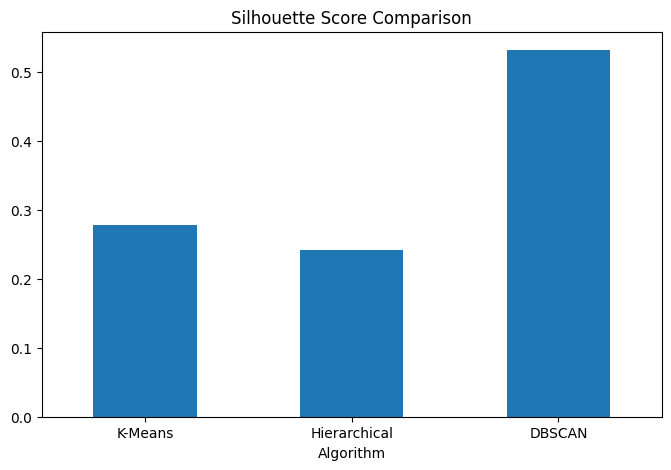

In [ ]:
results.plot(x='Algorithm', y='Silhouette Score', kind='bar', figsize=(8,5), legend=False)
plt.title("Silhouette Score Comparison")
plt.xticks(rotation=0)
plt.show()

- ​DBSCAN Dominates Separation:
DBSCAN achieves the highest score (\approx 0.53), proving it isolates dense core clusters and handles geometric noise far better than the other algorithms.

- ​K-Means Outperforms Hierarchical: K-Means achieves a moderate score (\approx 0.28), outperforming Hierarchical clustering (\approx 0.24) and confirming better structural cohesion across your defined customer segments.

- ​The Trade-Off: While DBSCAN scores highest by filtering out outliers, K-Means remains your ideal choice for the Streamlit dashboard because it forces an active operational segment assignment for every customer instead of discarding unclassifiable accounts as noise.

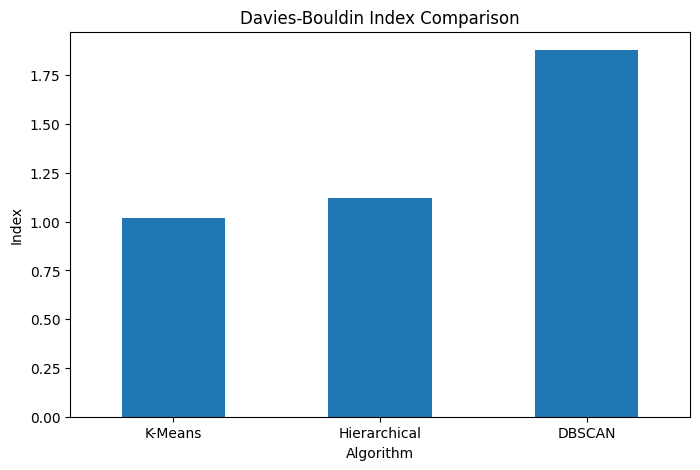

In [ ]:
results.plot(x='Algorithm', y='Davies-Bouldin Index', kind='bar', figsize=(8,5), legend=False)
plt.title("Davies-Bouldin Index Comparison")
plt.xticks(rotation=0)
plt.ylabel("Index")
plt.show()

- K-Means Wins on Compactness: K-Means achieves the lowest (best) Davies-Bouldin Index (\approx 1.02), proving its clusters have the tightest internal cohesion and clearest individual boundaries.

- ​Hierarchical Follows Closely: Agglomerative Hierarchical clustering performs moderately well (\approx 1.12), showing decent structural compactness but slightly more internal variance than K-Means.

- ​DBSCAN Struggles with Symmetry: DBSCAN registers the highest (worst) index (\approx 1.88). Because it creates arbitrary, density-based shapes rather than spherical boundaries, its structural compactness score is heavily penalized in an RFM distribution space.